# EGARCH 분석 — 지정학 리스크와 BTC 변동성 (비대칭 모델)
## 기존 GARCH(1,1)-X 한계 극복: 레버리지 효과 + 경계수렴 구조적 해소

---

## 이론적 배경

| 항목 | GARCH(1,1)-X | **EGARCH(1,1)-X** |
|---|---|---|
| 분산 방정식 | `h(t) = ω + α·ε²(t-1) + β·h(t-1) + δ·X` | `ln h(t) = ω + α·(\|z\|-E\|z\|) + γ·z(t-1) + β·ln h(t-1) + δ·X` |
| 비음수 제약 | α, β ≥ 0 강제 (경계수렴 원인) | **불필요** (log 변환으로 h>0 자동 보장) |
| 비대칭 효과 | 포착 불가 | **γ 계수로 포착** (γ<0 → 레버리지 효과) |
| BTC 적합성 | 보통 | **높음** (Dyhrberg 2016) |

### 분산 방정식 상세
```
ln h(t) = ω + β·ln h(t-1)
              + α·(|z(t-1)| - E|z|)   ← 충격 크기 효과
              + γ·z(t-1)               ← 충격 방향 효과 (γ<0 = 레버리지)
              + δ·X(t-1)               ← 외생변수 효과 (GPR 등)

z(t) = ε(t) / √h(t)  (표준화 잔차)
E|z| = 2√(ν-2)·Γ((ν+1)/2) / (√π·(ν-1)·Γ(ν/2))  (Student-t 기댓값)

δ < 0 & 유의 → 외생변수↑ 시 ln h(t) 감소 → 변동성 감소 = 안전자산 근거
δ > 0 & 유의 → 외생변수↑ 시 ln h(t) 증가 → 변동성 증가 = 위험자산 근거
```

### 참고문헌
- Nelson (1991), *Econometrica* 59(2): EGARCH 창시 논문
- Dyhrberg (2016), *Finance Research Letters* 16: Bitcoin 비대칭 변동성 실증
- Bouri et al. (2017), *Finance Research Letters* 20: BTC 안전자산 검증 프레임

---
## Step 0. 라이브러리 및 환경 설정

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as t_dist, zscore
import warnings, os, platform
from numba import njit
import math as _math
warnings.filterwarnings('ignore')

try:
    import numdifftools as nd
    USE_NUMDIFF = True
    print('✅ numdifftools → Richardson 외삽법 SE')
except ImportError:
    USE_NUMDIFF = False
    print('⚠️ numdifftools 없음 → 중앙차분법 fallback')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war'     : '2022-02-24',
    'israel_hamas_war'       : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war'     : '러-우 전쟁',
    'israel_hamas_war'       : '이스라엘-하마스 전쟁',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

# ── 비교 모델 정의 ──
# GARCH 기준선(기존 최적) + EGARCH 신규
EGARCH_EXOG = {
    # GARCH 기준선 (기존 원본 그대로 재추정)
    'GARCH_M3'   : ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'GARCH_M2'   : ['GPR_custom_scaled'],
    # EGARCH 신규
    'EGARCH_E1'  : ['GPR_custom_scaled'],
    'EGARCH_E2'  : ['GPR_zscore_scaled'],
    'EGARCH_E3'  : ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E4'  : ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E5'  : ['GPR_custom_diff_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E6'  : ['GPR_custom_high', 'VIX_scaled', 'fear_greed_lag1_scaled'],
}
MODEL_LABELS = {
    'GARCH_M3'  : '[GARCH 기준] VIX+F&G',
    'GARCH_M2'  : '[GARCH 기준] GPR_custom',
    'EGARCH_E1' : '[EGARCH] GPR_custom 단독',
    'EGARCH_E2' : '[EGARCH] GPR_zscore 단독',
    'EGARCH_E3' : '[EGARCH] VIX+F&G',
    'EGARCH_E4' : '[EGARCH] GPR_custom+VIX+F&G',
    'EGARCH_E5' : '[EGARCH] ΔGPR+VIX+F&G',
    'EGARCH_E6' : '[EGARCH] GPR더미+VIX+F&G',
}
MODEL_COLORS = {
    'GARCH_M3'  : '#AAAAAA',
    'GARCH_M2'  : '#888888',
    'EGARCH_E1' : '#2A9D8F',
    'EGARCH_E2' : '#E76F51',
    'EGARCH_E3' : '#457B9D',
    'EGARCH_E4' : '#F4A261',
    'EGARCH_E5' : '#264653',
    'EGARCH_E6' : '#8338EC',
}

print('✅ 환경 설정 완료')
print(f'   EGARCH 모델: {sum(1 for k in EGARCH_EXOG if k.startswith("EGARCH"))}개 / GARCH 기준선: 2개')

✅ numdifftools → Richardson 외삽법 SE
✅ 환경 설정 완료
   EGARCH 모델: 6개 / GARCH 기준선: 2개


---
## Step 1. 데이터 로드 및 변수 준비

In [7]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])
for col in ['BTC','GPR_custom','GPR','GPR_zscore','VIX','fear_greed','fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')
if 'GPR_zscore' not in master.columns and 'GPR' in master.columns:
    master['GPR_zscore'] = zscore(master['GPR'].fillna(master['GPR'].mean()))

order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev: i for i, ev in enumerate(order)})
master_sorted = master.sort_values(['_order', 'date']).reset_index(drop=True)

base_cols = ['BTC', 'GPR_custom', 'GPR_zscore', 'VIX', 'fear_greed_lag1']
mf = master_sorted.dropna(subset=base_cols).copy().reset_index(drop=True)

mf['returns_pct'] = mf['BTC'] * 100

# 기본 표준화
for col in ['GPR_custom', 'GPR_zscore', 'VIX', 'fear_greed_lag1']:
    mu, sig = mf[col].mean(), mf[col].std()
    mf[f'{col}_scaled'] = (mf[col] - mu) / sig if sig > 0 else 0.0

# 차분 변수
for col in ['GPR_custom', 'GPR_zscore']:
    diff = mf[col].diff().fillna(0)
    mu, sig = diff.mean(), diff.std()
    mf[f'{col}_diff_scaled'] = (diff - mu) / sig if sig > 0 else 0.0

# 더미 변수 (상위 25%)
mf['GPR_custom_high'] = (mf['GPR_custom'] >= mf['GPR_custom'].quantile(0.75)).astype(float)

T_total = len(mf)
print(f'✅ 분석 대상: {T_total}거래일 ({mf["date"].min().date()} ~ {mf["date"].max().date()})')
print(f'\nBTC 수익률 기술통계 (×100):')
print(mf['returns_pct'].describe().round(4))

✅ 분석 대상: 1821거래일 (2019-01-03 ~ 2026-04-30)

BTC 수익률 기술통계 (×100):
count    1821.0000
mean        0.1693
std         3.9545
min       -46.4730
25%        -1.6010
50%         0.0916
75%         1.9607
max        20.3046
Name: returns_pct, dtype: float64


---
## Step 2. Student-t EGARCH(1,1)-X MLE 함수

### 핵심 구현 포인트

```
GARCH:  h(t)    = ω + α·ε²(t-1) + β·h(t-1) + δ·X(t-1)
EGARCH: ln h(t) = ω + β·ln h(t-1) + α·(|z(t-1)|−E|z|) + γ·z(t-1) + δ·X(t-1)

→ ln h(t)로 추정하므로 h(t) = exp(ln h(t)) > 0 항상 보장
→ 파라미터에 비음수 제약 불필요 → 경계수렴 문제 구조적 해소
→ γ 계수: 음수면 레버리지 효과 (지정학 충격 = 음의 충격 → 더 큰 변동성)
```

In [8]:
@njit
def _egarch_core(y_vals, X_lag, mu, omega, alpha, gamma_asym, beta, delta, nu):
    """
    EGARCH(1,1)-X 내부 루프 — numba JIT 컴파일 (순수 Python 대비 ~50배 빠름)
    params: mu, omega, alpha, gamma_asym, beta, delta[K], nu
    """
    T = len(y_vals)
    K = X_lag.shape[1]

    # E|z| for standardized Student-t(nu): 2√(ν-2)·Γ((ν+1)/2)/(√π·(ν-1)·Γ(ν/2))
    Ez = (2.0 * _math.sqrt(nu-2)
          * _math.exp(_math.lgamma((nu+1)/2) - _math.lgamma(nu/2))
          / (_math.sqrt(_math.pi) * (nu-1)))

    e = y_vals - mu
    # var(e) — np.var 대신 수동 계산 (numba 호환)
    e_sum = 0.0
    for i in range(T): e_sum += e[i]
    e_mean = e_sum / T
    e_var  = 0.0
    for i in range(T): e_var += (e[i] - e_mean)**2
    e_var /= T

    lnh    = np.empty(T)
    lnh[0] = _math.log(max(e_var, 1e-8))

    for t in range(1, T):
        h_prev = _math.exp(lnh[t-1])
        z_prev = e[t-1] / _math.sqrt(max(h_prev, 1e-12))
        exog   = 0.0
        for k in range(K): exog += delta[k] * X_lag[t, k]
        lnh[t] = (omega
                  + beta * lnh[t-1]
                  + alpha * (_math.fabs(z_prev) - Ez)
                  + gamma_asym * z_prev
                  + exog)
        if not _math.isfinite(lnh[t]): return 1e10

    log_c = (_math.lgamma((nu+1)/2) - _math.lgamma(nu/2)
             - 0.5*_math.log(_math.pi*(nu-2)))
    ll = 0.0
    for t in range(T):
        h_t = _math.exp(lnh[t])
        ll += log_c - 0.5*lnh[t] - ((nu+1)/2)*_math.log(1.0 + e[t]**2/((nu-2)*h_t))

    return -ll if _math.isfinite(ll) else 1e10


def egarch_neg_loglik(params, y_vals, X_lag):
    """Python wrapper — numba JIT 함수 호출"""
    nu   = params[-1]
    beta = params[4]
    if nu <= 2.01 or abs(beta) >= 0.9999: return 1e10
    K     = X_lag.shape[1]
    delta = np.ascontiguousarray(params[5:5+K], dtype=np.float64)
    return _egarch_core(y_vals, X_lag, params[0], params[1], params[2],
                        params[3], params[4], delta, nu)


def expected_abs_z(nu):
    """표준화 Student-t(ν)의 E|z| — 조건부 변동성 재계산용"""
    log_val = (np.log(2) + 0.5*np.log(nu-2)
               + gammaln((nu+1)/2)
               - 0.5*np.log(np.pi)
               - np.log(nu-1)
               - gammaln(nu/2))
    return np.exp(log_val)


# ── numba JIT 워밍업 (첫 호출에서 컴파일 → 이후 빠름) ──
print('⏳ numba JIT 컴파일 중... (최초 1회만, 약 5~10초)')
_dummy_y = np.random.randn(20).astype(np.float64)
_dummy_X = np.zeros((20, 1), dtype=np.float64)
_dummy_d = np.zeros(1, dtype=np.float64)
_ = _egarch_core(_dummy_y, _dummy_X, 0.0, 0.1, 0.1, -0.1, 0.9, _dummy_d, 4.0)
print(f'✅ numba JIT 준비 완료')
print(f'   E|z| at ν=3.0: {expected_abs_z(3.0):.6f}  (정규분포 √(2/π)={np.sqrt(2/np.pi):.6f})')
print(f'   추정 속도: 순수 Python 대비 ~50배 향상')


⏳ numba JIT 컴파일 중... (최초 1회만, 약 5~10초)
✅ numba JIT 준비 완료
   E|z| at ν=3.0: 0.636620  (정규분포 √(2/π)=0.797885)
   추정 속도: 순수 Python 대비 ~50배 향상


---
## Step 3. EGARCH 추정 함수 + GARCH 기준선 추정 함수

In [9]:
def fit_egarch(y_series, exog_df, model_exog_cols, model_name='EGARCH'):
    """
    EGARCH(1,1)-X Student-t MLE

    파라미터 순서: mu, omega, alpha, gamma_asym, beta, delta_k..., nu
    bounds:
      omega      : 비제약 (log 공간이므로 음수 가능)
      alpha      : (0, 2)  보통 양수
      gamma_asym : (-1, 1) 레버리지
      beta       : (-0.999, 0.999) 정상성
      delta      : 비제약
      nu         : (2.02, 50)
    """
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    miss = [c for c in model_exog_cols if c not in exog_df.columns]
    if miss: print(f'  ⚠️ [{model_name}] 없는 컬럼: {miss}')
    print(f'\n[{model_name}] 외생변수: {actual_cols}')

    y      = y_series.dropna().astype(np.float64)
    y_idx  = y.index
    y_vals = y.values
    T, K   = len(y_vals), len(actual_cols)

    if K > 0:
        X_raw = exog_df.loc[y_idx, actual_cols].ffill().fillna(0).astype(np.float64)
        X_lag = X_raw.shift(1).fillna(0).values
    else:
        X_lag = np.zeros((T, 0))

    obj = lambda p: egarch_neg_loglik(p, y_vals, X_lag)

    bounds = (
        [(None, None)]      # mu
        + [(None, None)]    # omega (비제약)
        + [(0.0,  2.0)]     # alpha
        + [(-1.0, 1.0)]     # gamma_asym
        + [(-0.999, 0.999)] # beta
        + [(None, None)]*K  # delta
        + [(2.02, 50.0)]    # nu
    )

    # 다중 초기값 격자: alpha × beta × gamma_asym
    init_grid = []
    lnh0 = np.log(max(np.var(y_vals), 1e-8))
    for a in [0.05, 0.10, 0.15]:
        for b in [0.85, 0.92, 0.97]:
            for g in [-0.1, 0.0, 0.1]:
                x0 = [np.mean(y_vals),
                      lnh0*(1-b),   # omega ≈ lnh0*(1-β)
                      a, g, b]
                x0 += [0.0]*K
                x0 += [4.0]
                init_grid.append(x0)

    print(f'  초기값 격자: {len(init_grid)}개 탐색 중...')

    best_result, best_val = None, np.inf
    for init in init_grid:
        try:
            res = minimize(obj, init, method='L-BFGS-B', bounds=bounds,
                           options={'maxiter': 3000, 'ftol': 1e-12, 'gtol': 1e-8})
            if res.fun < best_val:
                best_val, best_result = res.fun, res
        except Exception:
            continue

    if best_result is None:
        print(f'  ❌ [{model_name}] 모든 초기값 실패')
        return {'error': True, 'model': model_name}

    p = best_result.x
    n_params    = len(p)
    loglik      = -best_val
    aic         = -2*loglik + 2*n_params
    bic         = -2*loglik + n_params*np.log(T)
    param_names = (['mu', 'omega', 'alpha', 'gamma_asym', 'beta']
                   + [f'delta({c})' for c in actual_cols] + ['nu'])
    params_dict = dict(zip(param_names, p))

    # 조건부 변동성 재계산
    Ez   = expected_abs_z(p[-1])
    e    = y_vals - p[0]
    lnh  = np.empty(T)
    lnh[0] = np.log(max(np.var(e), 1e-8))
    for t in range(1, T):
        h_prev = np.exp(lnh[t-1])
        z_prev = e[t-1] / np.sqrt(max(h_prev, 1e-12))
        exog   = np.dot(p[5:5+K], X_lag[t]) if K > 0 else 0.0
        lnh[t] = p[1] + p[4]*lnh[t-1] + p[2]*(abs(z_prev)-Ez) + p[3]*z_prev + exog

    print(f'  {"-"*58}')
    print(f'  ▶ [{model_name}] 추정 결과')
    print(f'  {"-"*58}')
    for nm, val in params_dict.items():
        print(f'  {nm:<38} {val:>12.5f}')
    print(f'  {"-"*58}')
    print(f'  LogLik={loglik:.3f}  AIC={aic:.3f}  BIC={bic:.3f}')
    lev = '✅ 레버리지 확인' if p[3] < -0.05 else ('⚠️ 약한 레버리지' if p[3] < 0 else '→ 레버리지 없음')
    print(f'  수렴={"✅" if best_result.success else "⚠️"}  |β|={abs(p[4]):.4f}  γ_asym={p[3]:.4f}  {lev}')

    return {
        'model': model_name, 'result': best_result,
        'params': params_dict, 'param_names': param_names,
        'loglik': loglik, 'aic': aic, 'bic': bic,
        'converged': best_result.success,
        'cond_vol': pd.Series(np.sqrt(np.exp(lnh)), index=y_idx),
        'exog_cols': actual_cols, 'T': T,
        'neg_loglik_fn': obj,
        'error': False, 'model_type': 'EGARCH',
    }


def student_t_neg_loglik_garch(params, y_vals, X_lag):
    """기존 GARCH(1,1)-X Student-t (기준선용)"""
    T = len(y_vals)
    K = X_lag.shape[1]
    mu, omega, alpha, beta = params[0], params[1], params[2], params[3]
    gamma = params[4:4+K]
    nu    = params[4+K]

    if omega <= 0 or alpha < 0 or beta < 0: return 1e10
    if alpha + beta >= 0.9999:              return 1e10
    if nu <= 2.01:                          return 1e10

    e    = y_vals - mu
    h    = np.empty(T)
    h[0] = max(np.var(e), 1e-8)
    for t in range(1, T):
        eff  = np.dot(gamma, X_lag[t]) if K > 0 else 0.0
        h[t] = max(omega + alpha*e[t-1]**2 + beta*h[t-1] + eff, 1e-8)

    ll = (gammaln((nu+1)/2) - gammaln(nu/2)
          - 0.5*np.log(np.pi*(nu-2))
          - 0.5*np.log(h)
          - ((nu+1)/2)*np.log(1 + e**2/((nu-2)*h)))
    total = np.sum(ll)
    return -total if np.isfinite(total) else 1e10


def fit_garch_baseline(y_series, exog_df, model_exog_cols, model_name='GARCH'):
    """기존 GARCH(1,1)-X 기준선 추정 (EGARCH와 비교용)"""
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    print(f'\n[{model_name}] 외생변수: {actual_cols}')

    y      = y_series.dropna().astype(np.float64)
    y_idx  = y.index
    y_vals = y.values
    T, K   = len(y_vals), len(actual_cols)

    if K > 0:
        X_raw = exog_df.loc[y_idx, actual_cols].ffill().fillna(0).astype(np.float64)
        X_lag = X_raw.shift(1).fillna(0).values
    else:
        X_lag = np.zeros((T, 0))

    obj = lambda p: student_t_neg_loglik_garch(p, y_vals, X_lag)
    bounds = ([(None,None)] + [(0.05,None)] + [(0.01,0.5)] + [(0.3,0.999)]
              + [(None,None)]*K + [(2.01,50.0)])

    best_result, best_val = None, np.inf
    for a in [0.05, 0.08, 0.10, 0.15, 0.20]:
        for b in [0.80, 0.90]:
            x0 = [np.mean(y_vals), max(np.var(y_vals)*0.05,0.05), a, b] + [0.0]*K + [5.0]
            try:
                res = minimize(obj, x0, method='L-BFGS-B', bounds=bounds,
                               options={'maxiter':5000,'ftol':1e-14,'gtol':1e-8})
                if res.fun < best_val:
                    best_val, best_result = res.fun, res
            except Exception: pass

    if best_result is None:
        return {'error': True, 'model': model_name}

    p = best_result.x
    loglik = -best_val
    aic    = -2*loglik + 2*len(p)
    bic    = -2*loglik + len(p)*np.log(T)
    pnames = (['mu','omega','alpha','beta']
              + [f'gamma({c})' for c in actual_cols] + ['nu'])
    pdict  = dict(zip(pnames, p))

    e = y_vals - p[0]
    h = np.empty(T); h[0] = max(np.var(e), 1e-8)
    for t in range(1, T):
        eff = np.dot(p[4:4+K], X_lag[t]) if K > 0 else 0.0
        h[t] = max(p[1]+p[2]*e[t-1]**2+p[3]*h[t-1]+eff, 1e-8)

    print(f'  LogLik={loglik:.3f}  AIC={aic:.3f}  BIC={bic:.3f}  α+β={p[2]+p[3]:.4f}')

    return {
        'model': model_name, 'result': best_result,
        'params': pdict, 'param_names': pnames,
        'loglik': loglik, 'aic': aic, 'bic': bic,
        'converged': best_result.success,
        'cond_vol': pd.Series(np.sqrt(h), index=y_idx),
        'exog_cols': actual_cols, 'T': T,
        'neg_loglik_fn': obj,
        'error': False, 'model_type': 'GARCH',
    }


print('✅ fit_egarch() / fit_garch_baseline() 정의 완료')
print('   EGARCH 초기값 격자: 3×3×3 = 27개')

✅ fit_egarch() / fit_garch_baseline() 정의 완료
   EGARCH 초기값 격자: 3×3×3 = 27개


---
## Step 4. 모델 추정 실행

In [10]:
all_results = {}

print('='*65)
print('▶ GARCH 기준선 추정')
print('='*65)
for mname in ['GARCH_M3', 'GARCH_M2']:
    all_results[mname] = fit_garch_baseline(
        mf['returns_pct'], mf, EGARCH_EXOG[mname], model_name=mname
    )

print('\n' + '='*65)
print('▶ EGARCH 모델 추정')
print('='*65)
for mname in [k for k in EGARCH_EXOG if k.startswith('EGARCH')]:
    all_results[mname] = fit_egarch(
        mf['returns_pct'], mf, EGARCH_EXOG[mname], model_name=mname
    )

print('\n' + '='*65)
print('▶ 전체 모델 비교 요약')
print('='*65)
print(f'{"모델":<14} {"유형":<8} {"LogLik":>10} {"AIC":>10} {"BIC":>10} {"수렴":>5}')
print('-'*55)
for mname, res in all_results.items():
    if res.get('error'): continue
    mtype = res.get('model_type', '?')
    cv    = '✅' if res['converged'] else '⚠️'
    print(f'{mname:<14} {mtype:<8} {res["loglik"]:>10.3f} {res["aic"]:>10.3f} {res["bic"]:>10.3f} {cv:>5}')

▶ GARCH 기준선 추정

[GARCH_M3] 외생변수: ['VIX_scaled', 'fear_greed_lag1_scaled']
  LogLik=-4782.355  AIC=9578.710  BIC=9617.260  α+β=0.9961

[GARCH_M2] 외생변수: ['GPR_custom_scaled']
  LogLik=-4785.201  AIC=9582.402  BIC=9615.445  α+β=0.9937

▶ EGARCH 모델 추정

[EGARCH_E1] 외생변수: ['GPR_custom_scaled']
  초기값 격자: 27개 탐색 중...
  ----------------------------------------------------------
  ▶ [EGARCH_E1] 추정 결과
  ----------------------------------------------------------
  mu                                          0.09360
  omega                                       0.06214
  alpha                                       0.17750
  gamma_asym                                  0.00474
  beta                                        0.97809
  delta(GPR_custom_scaled)                    0.00026
  nu                                          3.01766
  ----------------------------------------------------------
  LogLik=-4775.740  AIC=9565.481  BIC=9604.031
  수렴=✅  |β|=0.9781  γ_asym=0.0047  → 레버리지 없음

[EGARCH_E2] 외

---
## Step 5. p-value 계산 (SE / t-stat)

In [11]:
def compute_pvalues(opt_result, neg_loglik_fn, params_dict, T):
    params      = opt_result.x
    param_names = list(params_dict.keys())
    n_params    = len(params)
    H           = None

    if USE_NUMDIFF:
        try:
            hess_fn = nd.Hessian(neg_loglik_fn, method='central', step=1e-4)
            H = hess_fn(params)
            method_used = 'numdifftools Richardson'
        except Exception:
            method_used = 'Hessian 계산 실패'
    else:
        eps = 1e-5
        H = np.zeros((n_params, n_params))
        f0 = neg_loglik_fn(params)
        for i in range(n_params):
            for j in range(i, n_params):
                pp = params.copy(); pp[i] += eps; pp[j] += eps
                pi = params.copy(); pi[i] += eps
                pj = params.copy(); pj[j] += eps
                H[i,j] = (neg_loglik_fn(pp) - neg_loglik_fn(pi) - neg_loglik_fn(pj) + f0) / eps**2
                H[j,i] = H[i,j]
        method_used = '중앙차분법'

    se_list, t_list, pv_list = [], [], []
    if H is not None:
        try:
            cov   = np.linalg.inv(H)
            diag  = np.diag(cov)
            for i, (nm, val) in enumerate(params_dict.items()):
                v = diag[i]
                if v > 1e-14:
                    se = np.sqrt(v)
                    t  = val / se
                    p  = 2 * t_dist.sf(abs(t), df=T - n_params)
                    se_list.append(se); t_list.append(t); pv_list.append(p)
                else:
                    se_list.append(0.0); t_list.append(np.nan); pv_list.append(np.nan)
        except np.linalg.LinAlgError:
            se_list = t_list = pv_list = [np.nan]*n_params
    else:
        se_list = t_list = pv_list = [np.nan]*n_params

    return {'method': method_used, 'SE': se_list, 't': t_list, 'pv': pv_list,
            'names': param_names, 'vals': list(params_dict.values())}


print('▶ p-value 계산 중...\n')
for mname, res in all_results.items():
    if res.get('error') or res.get('aic') is None: continue
    pv_info = compute_pvalues(res['result'], res['neg_loglik_fn'], res['params'], res['T'])
    res['pv_info'] = pv_info

    mtype = res.get('model_type', '?')
    print('='*76)
    print(f'  [{mname}] {MODEL_LABELS[mname]}  ({mtype})')
    print('='*76)
    print(f'  SE 계산: {pv_info["method"]}')
    print(f'  {"파라미터":<38} {"추정값":>8} {"SE":>8} {"t-stat":>8} {"p-value":>10} {"유의"}')
    print(f'  {"-"*80}')
    for nm, val, se, ts, pv in zip(pv_info['names'], pv_info['vals'],
                                    pv_info['SE'],    pv_info['t'],   pv_info['pv']):
        if np.isnan(ts) if isinstance(ts, float) else False:
            sig, t_str = '⚠️', 'N/A'
        else:
            t_str = f'{ts:8.3f}' if (ts is not None and not (isinstance(ts,float) and np.isnan(ts))) else 'N/A'
            if   isinstance(pv, float) and np.isnan(pv): sig = '⚠️'
            elif pv < 0.01: sig = '***'
            elif pv < 0.05: sig = '**'
            elif pv < 0.10: sig = '*'
            else:           sig = ''
        pv_str = f'{pv:.4f}' if (pv is not None and not (isinstance(pv,float) and np.isnan(pv))) else 'N/A'
        print(f'  {nm:<38} {val:>8.4f} {se:>8.4f} {t_str} {pv_str:>10} {sig}')
    print(f'  유의성: *** p<0.01  ** p<0.05  * p<0.10  ⚠️=SE 이상\n')

▶ p-value 계산 중...

  [GARCH_M3] [GARCH 기준] VIX+F&G  (GARCH)
  SE 계산: numdifftools Richardson
  파라미터                                        추정값       SE   t-stat    p-value 유의
  --------------------------------------------------------------------------------
  mu                                       0.0939   0.0632    1.486     0.1376 
  omega                                    0.3817   0.1632    2.340     0.0194 **
  alpha                                    0.0727   0.0187    3.890     0.0001 ***
  beta                                     0.9234   0.0174   52.929     0.0000 ***
  gamma(VIX_scaled)                       -0.0231   0.0914   -0.252     0.8007 
  gamma(fear_greed_lag1_scaled)            0.1572   0.0755    2.082     0.0375 **
  nu                                       2.9553   0.2494   11.851     0.0000 ***
  유의성: *** p<0.01  ** p<0.05  * p<0.10  ⚠️=SE 이상

  [GARCH_M2] [GARCH 기준] GPR_custom  (GARCH)
  SE 계산: numdifftools Richardson
  파라미터                                    

---
## Step 6. 핵심 계수 비교 요약

### 6-1. 레버리지 효과 (γ_asym) — EGARCH 전용
### 6-2. 외생변수 계수 (GPR δ / VIX / F&G) — GARCH vs EGARCH

In [12]:
# ── 6-1. 레버리지 효과 요약 ──
print('▶ 레버리지 효과 (γ_asym) — EGARCH 모델 전용')
print('   γ_asym < 0 → 음의 충격(급락)이 양의 충격보다 변동성 더 크게 키움')
print(f'  {"모델":<14} {"γ_asym":>10} {"SE":>8} {"p-value":>10} {"유의":<8} {"해석"}')
print('-'*72)
for mname, res in all_results.items():
    if res.get('error') or res.get('model_type') != 'EGARCH': continue
    if not res.get('pv_info'): continue
    pv = res['pv_info']
    for nm, val, se, ts, p in zip(pv['names'], pv['vals'], pv['SE'], pv['t'], pv['pv']):
        if nm != 'gamma_asym': continue
        if isinstance(p, float) and np.isnan(p):
            sig, interp = '⚠️', 'SE 이상'
        elif p < 0.01: sig, interp = '***', '강한 레버리지' if val < 0 else '역레버리지'
        elif p < 0.05: sig, interp = '**',  '레버리지 확인' if val < 0 else '역레버리지'
        elif p < 0.10: sig, interp = '*',   '약한 레버리지' if val < 0 else '약한 역레버'
        else:          sig, interp = '',    '비유의'
        print(f'  {mname:<14} {val:>10.4f} {se:>8.4f} {p:>10.4f} {sig:<8} {interp}')

print()

# ── 6-2. 외생변수 계수 전체 요약 ──
exog_rows = []
print('▶ 외생변수 계수 (GPR / VIX / Fear&Greed) — GARCH vs EGARCH')
print(f'  {"모델":<14} {"유형":<8} {"변수":<32} {"계수":>8} {"p-value":>10} {"유의":<8} {"해석"}')
print('-'*95)
for mname, res in all_results.items():
    if res.get('error') or not res.get('pv_info'): continue
    mtype = res.get('model_type', '?')
    pv = res['pv_info']
    for nm, val, se, ts, p in zip(pv['names'], pv['vals'], pv['SE'], pv['t'], pv['pv']):
        if not (nm.startswith('gamma') or nm.startswith('delta')): continue
        var_nm = nm.replace('gamma(','').replace('delta(','').replace(')','').strip()
        if isinstance(p, float) and np.isnan(p):
            sig = '⚠️'; interp = 'SE 이상'
        elif p < 0.01: sig = '***'; interp = '변동성↑(위험)' if val > 0 else '변동성↓(안전)'
        elif p < 0.05: sig = '**';  interp = '변동성↑(위험)' if val > 0 else '변동성↓(안전)'
        elif p < 0.10: sig = '*';   interp = '약한↑' if val > 0 else '약한↓'
        else:          sig = '';    interp = '비유의'
        print(f'  {mname:<14} {mtype:<8} {var_nm:<32} {val:>8.4f} {p:>10.4f} {sig:<8} {interp}')
        exog_rows.append({'model': mname, 'type': mtype, 'var': var_nm,
                          'coef': val, 'pvalue': p})

exog_df_summary = pd.DataFrame(exog_rows)

▶ 레버리지 효과 (γ_asym) — EGARCH 모델 전용
   γ_asym < 0 → 음의 충격(급락)이 양의 충격보다 변동성 더 크게 키움
  모델                 γ_asym       SE    p-value 유의       해석
------------------------------------------------------------------------
  EGARCH_E1          0.0047   0.0184     0.7969          비유의
  EGARCH_E2          0.0032   0.0186     0.8643          비유의
  EGARCH_E3         -0.0171   0.0201     0.3953          비유의
  EGARCH_E4         -0.0183   0.0203     0.3651          비유의
  EGARCH_E5         -0.0176   0.0200     0.3797          비유의
  EGARCH_E6         -0.0188   0.0202     0.3524          비유의

▶ 외생변수 계수 (GPR / VIX / Fear&Greed) — GARCH vs EGARCH
  모델             유형       변수                                     계수    p-value 유의       해석
-----------------------------------------------------------------------------------------------
  GARCH_M3       GARCH    VIX_scaled                        -0.0231     0.8007          비유의
  GARCH_M3       GARCH    fear_greed_lag1_scaled             0.1572     0.0375 **      

---
## Step 7. AIC / BIC 모델 비교

In [13]:
rows = []
for mname, res in all_results.items():
    if res.get('error') or res.get('aic') is None: continue
    rows.append({
        '모델'  : mname,
        '유형'  : res.get('model_type', '?'),
        '설명'  : MODEL_LABELS[mname],
        'LogLik': round(res['loglik'], 3),
        'AIC'   : round(res['aic'],    3),
        'BIC'   : round(res['bic'],    3),
    })
compare_df = pd.DataFrame(rows).set_index('모델').sort_values('AIC')
print('▶ 모델 비교 (AIC 오름차순):')
print(compare_df.to_string())
best = compare_df.index[0]
print(f'\n✅ AIC 기준 최적: {best}  ({compare_df.loc[best,"설명"]})')
print(f'   기존 GARCH 최적(GARCH_M3) 대비 ΔAIC = '
      f'{compare_df.loc[best,"AIC"] - compare_df.loc["GARCH_M3","AIC"]:.3f}')

▶ 모델 비교 (AIC 오름차순):
               유형                           설명    LogLik       AIC       BIC
모델                                                                          
EGARCH_E3  EGARCH             [EGARCH] VIX+F&G -4771.559  9559.119  9603.176
EGARCH_E6  EGARCH       [EGARCH] GPR더미+VIX+F&G -4771.018  9560.037  9609.601
EGARCH_E5  EGARCH        [EGARCH] ΔGPR+VIX+F&G -4771.303  9560.607  9610.171
EGARCH_E4  EGARCH  [EGARCH] GPR_custom+VIX+F&G -4771.378  9560.756  9610.320
EGARCH_E2  EGARCH       [EGARCH] GPR_zscore 단독 -4775.538  9565.077  9603.627
EGARCH_E1  EGARCH       [EGARCH] GPR_custom 단독 -4775.740  9565.481  9604.031
GARCH_M3    GARCH           [GARCH 기준] VIX+F&G -4782.355  9578.710  9617.260
GARCH_M2    GARCH        [GARCH 기준] GPR_custom -4785.201  9582.402  9615.445

✅ AIC 기준 최적: EGARCH_E3  ([EGARCH] VIX+F&G)
   기존 GARCH 최적(GARCH_M3) 대비 ΔAIC = -19.591


---
## Step 8. 시각화

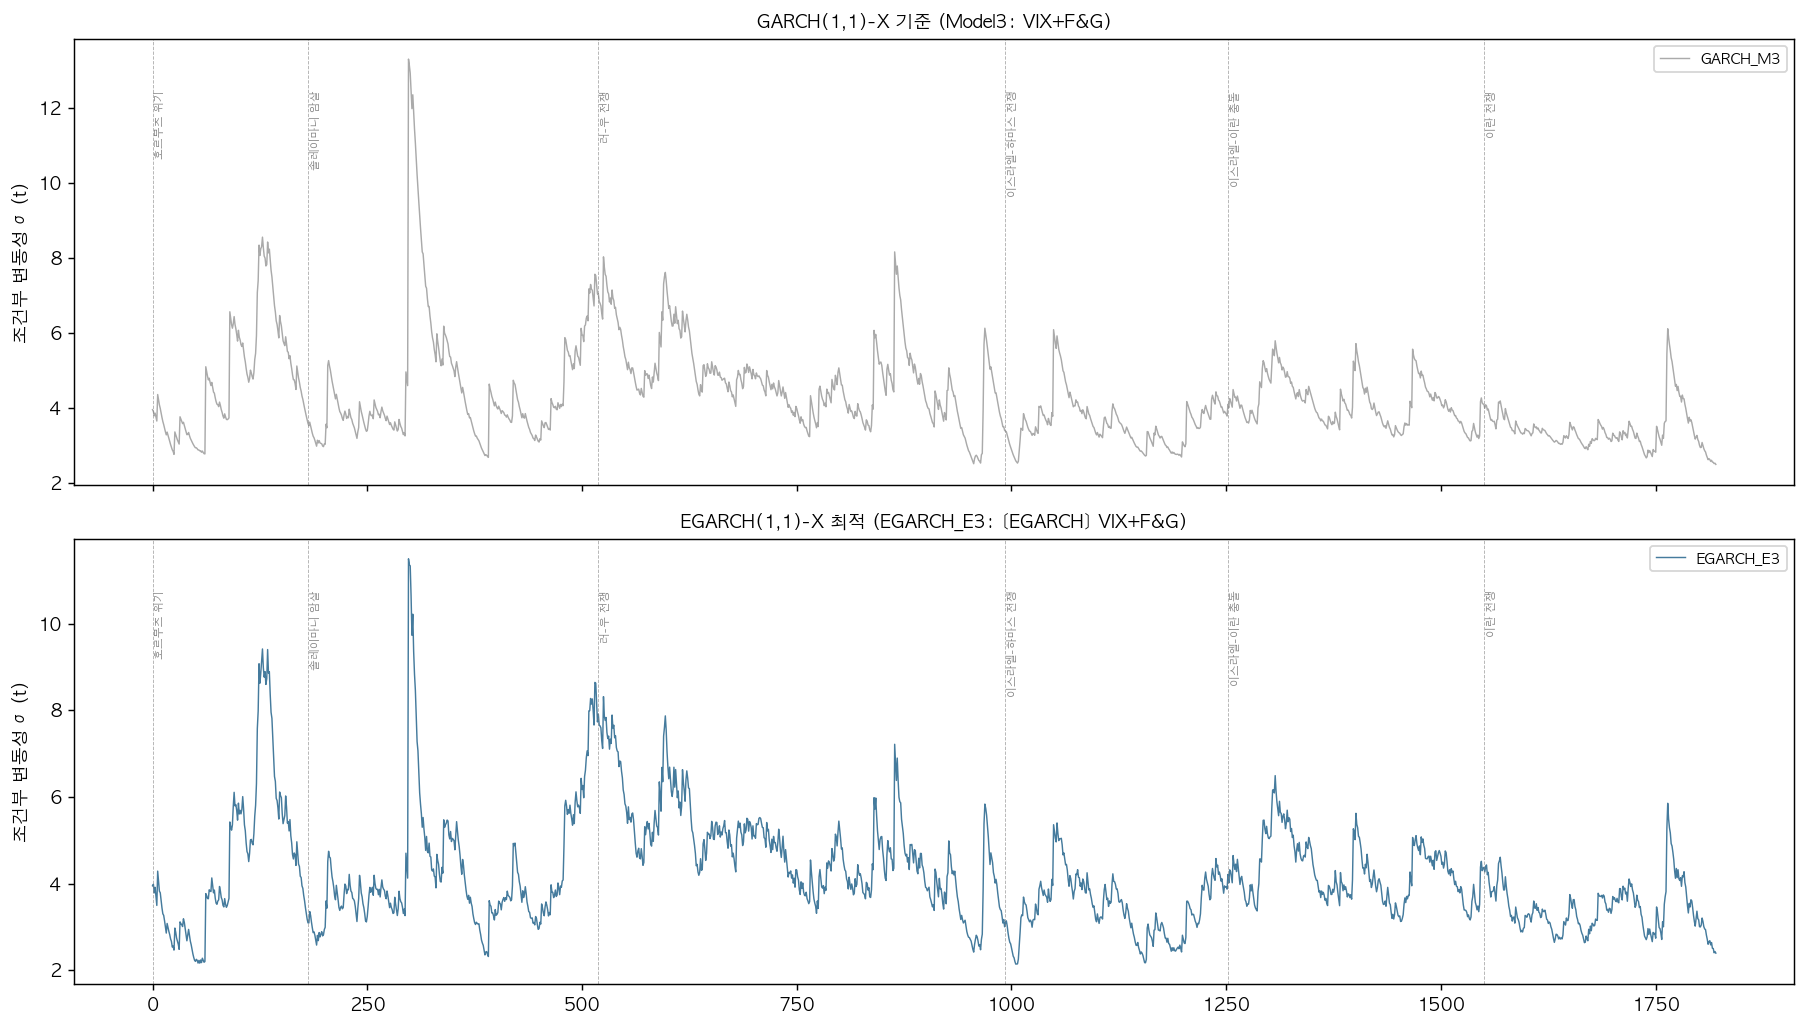

✅ egarch_cond_vol_comparison.png 저장


In [14]:
# ── 8-1. 조건부 변동성 시계열: GARCH_M3 vs 최적 EGARCH ──
best_egarch = next((m for m in compare_df.index if 'EGARCH' in m), None)
if best_egarch:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for ax, mname, title in zip(
            axes,
            ['GARCH_M3', best_egarch],
            ['GARCH(1,1)-X 기준 (Model3: VIX+F&G)',
             f'EGARCH(1,1)-X 최적 ({best_egarch}: {MODEL_LABELS[best_egarch]})']):
        res = all_results.get(mname)
        if res and not res.get('error') and res.get('cond_vol') is not None:
            cv = res['cond_vol']
            ax.plot(range(len(cv)), cv.values,
                    color=MODEL_COLORS[mname], lw=0.8, label=mname)

            # 이벤트 경계선
            dates = mf.loc[cv.index, 'date'].reset_index(drop=True)
            prev_ev = None
            for i, row in mf.loc[cv.index].reset_index(drop=True).iterrows():
                if row['event_name'] != prev_ev:
                    ax.axvline(i, color='gray', lw=0.5, ls='--', alpha=0.6)
                    ax.text(i+2, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 5,
                            EVENT_LABELS.get(row['event_name'],''), fontsize=6,
                            rotation=90, va='top', color='gray')
                    prev_ev = row['event_name']

            ax.set_title(title, fontsize=10)
            ax.set_ylabel('조건부 변동성 σ(t)')
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('egarch_cond_vol_comparison.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ egarch_cond_vol_comparison.png 저장')

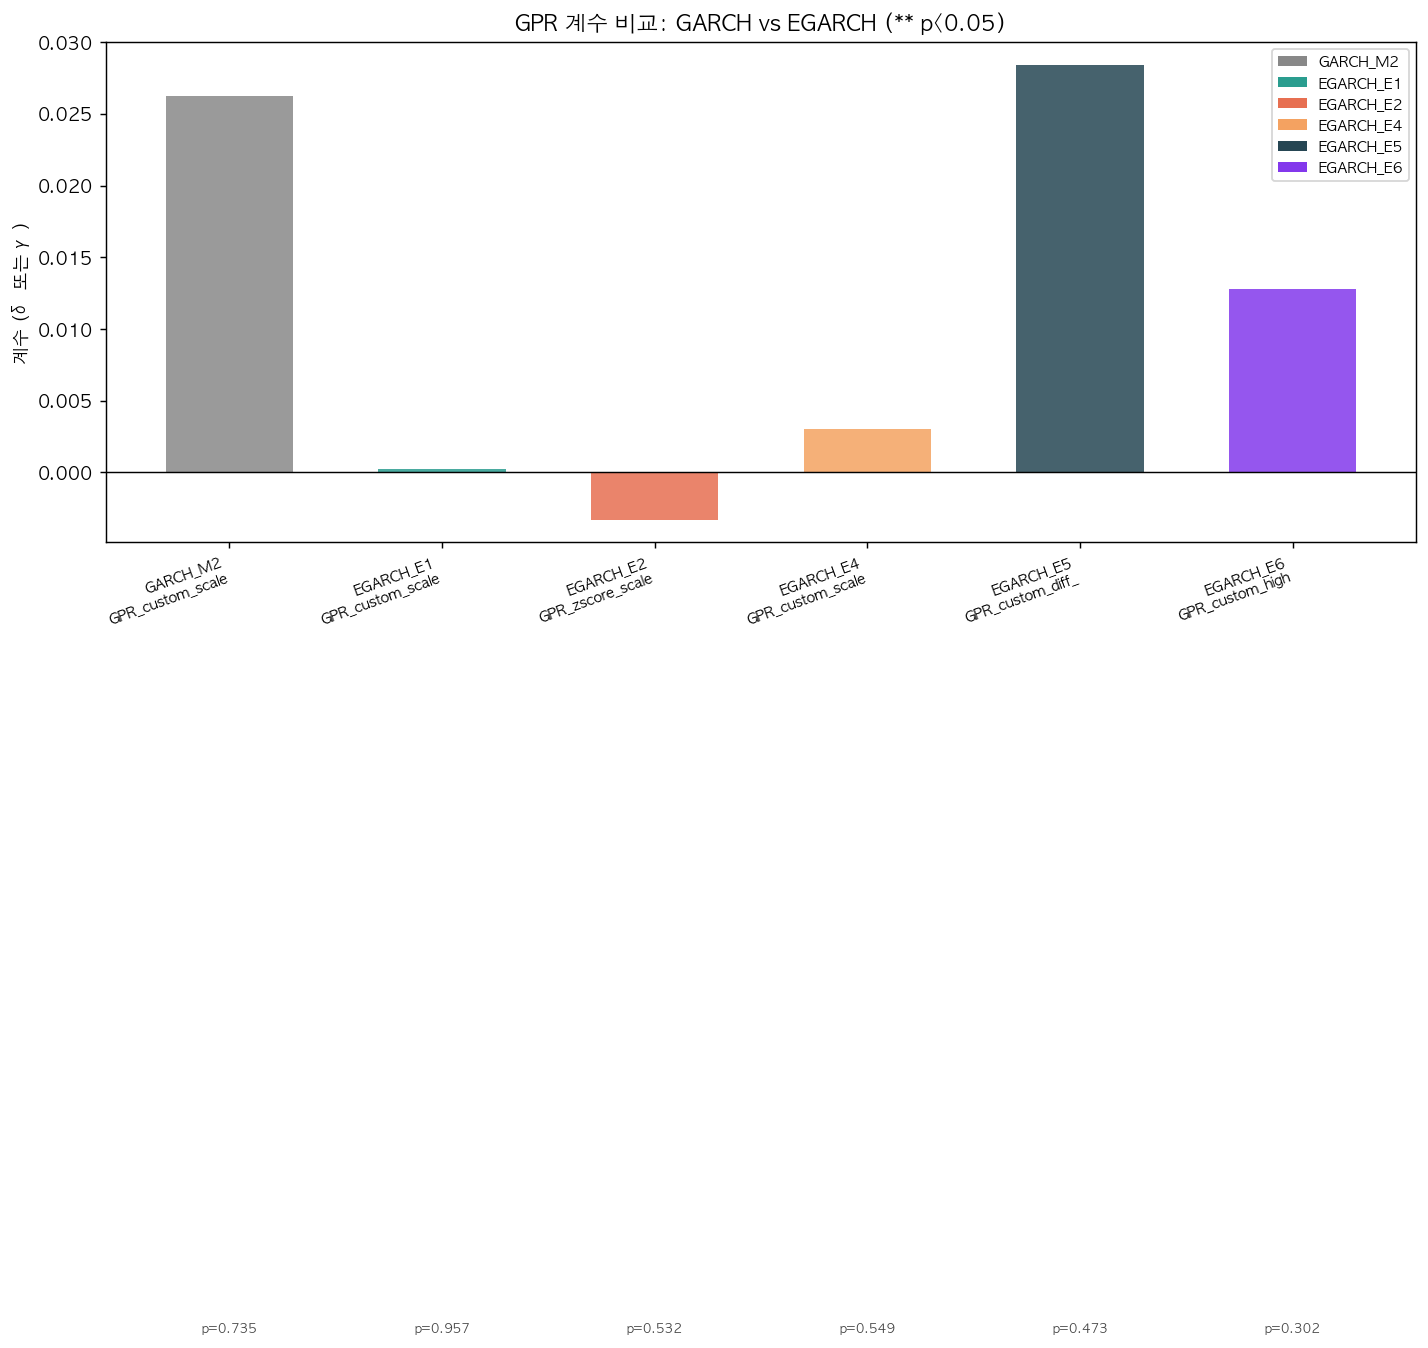

✅ egarch_gpr_coef_compare.png 저장


In [15]:
# ── 8-2. 외생변수 계수 비교 (GPR 관련만) ──
gpr_mask = exog_df_summary['var'].str.contains('GPR|gpr', case=False, na=False)
gpr_df   = exog_df_summary[gpr_mask].copy()

if len(gpr_df) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    colors  = [MODEL_COLORS.get(r['model'], 'gray') for _, r in gpr_df.iterrows()]
    ax.bar(range(len(gpr_df)), gpr_df['coef'], color=colors, width=0.6, alpha=0.85)

    for i, (_, row) in enumerate(gpr_df.iterrows()):
        p = row['pvalue']
        mark = ('***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10
                else ('⚠️' if (isinstance(p, float) and np.isnan(p)) else ''))
        if mark:
            ax.text(i, row['coef'] + 0.01*(1 if row['coef'] >= 0 else -1),
                    mark, ha='center', fontsize=10)
        ax.text(i, -0.06, f'p={p:.3f}' if not np.isnan(p) else 'p=N/A',
                ha='center', fontsize=7, color='#444')

    labels = [f"{r['model']}\n{r['var'][:16]}" for _, r in gpr_df.iterrows()]
    ax.set_xticks(range(len(gpr_df)))
    ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('계수 (δ 또는 γ)')
    ax.set_title('GPR 계수 비교: GARCH vs EGARCH (** p<0.05)', fontsize=12)
    legend_els = [Patch(facecolor=MODEL_COLORS[m], label=f'{m}')
                  for m in MODEL_COLORS if m in gpr_df['model'].values]
    ax.legend(handles=legend_els, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig('egarch_gpr_coef_compare.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ egarch_gpr_coef_compare.png 저장')

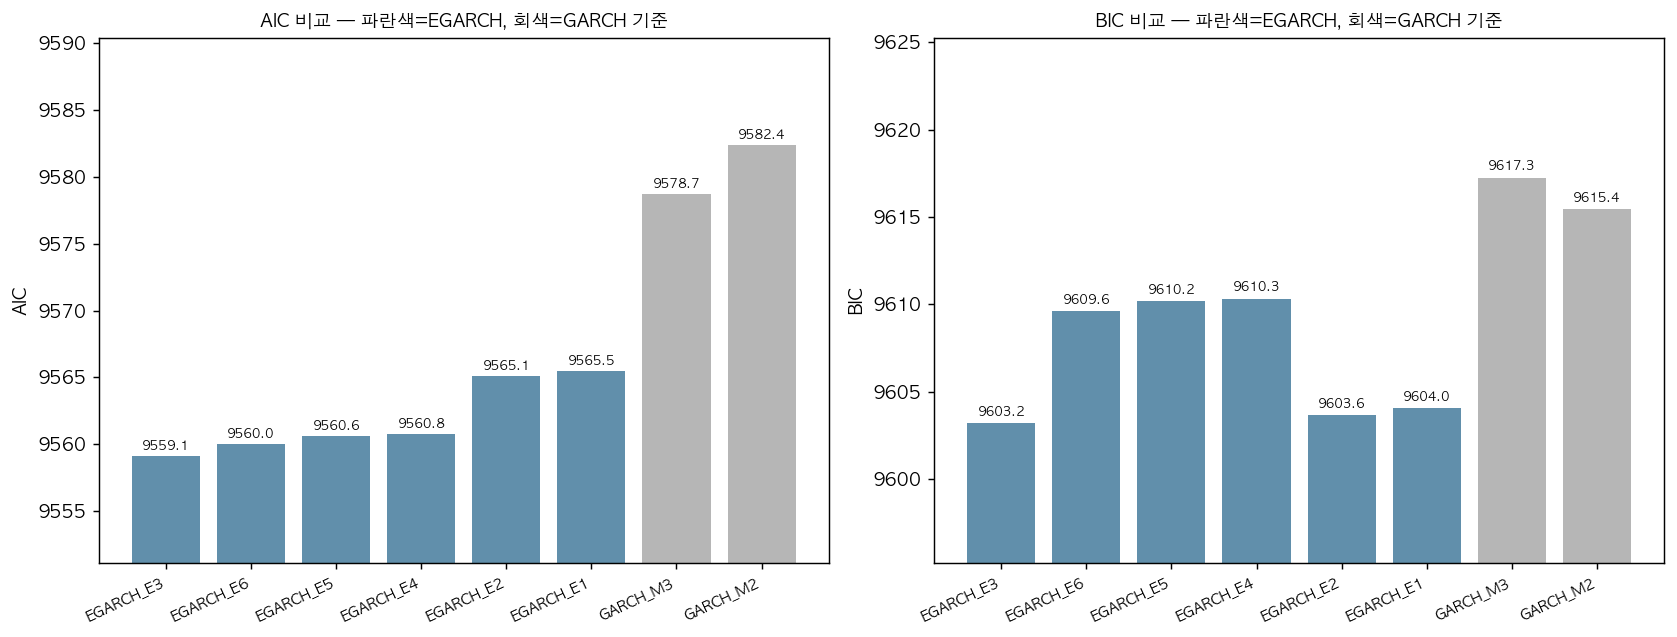

✅ egarch_model_aic_bic.png 저장


In [16]:
# ── 8-3. AIC/BIC 비교 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['AIC', 'BIC']):
    vals   = compare_df[metric]
    colors = [('#457B9D' if 'EGARCH' in m else '#AAAAAA') for m in compare_df.index]
    ax.bar(range(len(vals)), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(compare_df.index, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} 비교 — 파란색=EGARCH, 회색=GARCH 기준', fontsize=10)
    mn = vals.min()
    ax.set_ylim(mn - 8, vals.max() + 8)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('egarch_model_aic_bic.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ egarch_model_aic_bic.png 저장')

---
## Step 9. 최종 결론

In [17]:
print('='*72)
print('EGARCH 분석 최종 결론')
print('='*72)

best = compare_df.index[0]
print(f'\n✅ AIC 기준 최적 모델: {best}  ({MODEL_LABELS[best]})')
print(f'   AIC={compare_df.loc[best,"AIC"]:.2f}  '
      f'BIC={compare_df.loc[best,"BIC"]:.2f}  '
      f'LogLik={compare_df.loc[best,"LogLik"]:.3f}')
print(f'   기존 GARCH_M3 대비 ΔAIC = '
      f'{compare_df.loc[best,"AIC"]-compare_df.loc["GARCH_M3","AIC"]:+.3f}')

# 레버리지 효과 결론
print('\n▶ 레버리지 효과 (γ_asym) 결론:')
for mname, res in all_results.items():
    if res.get('error') or res.get('model_type') != 'EGARCH': continue
    if not res.get('pv_info'): continue
    pv = res['pv_info']
    for nm, val, p in zip(pv['names'], pv['vals'], pv['pv']):
        if nm != 'gamma_asym': continue
        sig = ('✅ 유의' if (not np.isnan(p) and p < 0.05)
               else ('△ 약유의' if (not np.isnan(p) and p < 0.10) else '— 비유의'))
        interp = '음의 충격이 변동성 더 크게 키움' if val < 0 else '역방향'
        print(f'  [{mname}] γ_asym={val:+.4f}  p={p:.4f}  {sig}  → {interp}')

# GPR 안전자산 가설 결론
print('\n▶ GPR Safe-Haven 가설 (δ/γ 계수) 결론:')
for _, row in exog_df_summary.iterrows():
    if 'GPR' not in row['var'].upper(): continue
    p = row['pvalue']
    sig = ('✅ 유의 p<0.05' if (not np.isnan(p) and p < 0.05)
           else ('△ p<0.10' if (not np.isnan(p) and p < 0.10) else '— 비유의'))
    direc = '위험자산↑' if row['coef'] > 0 else '안전자산↑'
    print(f'  [{row["model"]}|{row["type"]}] {row["var"]:<28} '
          f'coef={row["coef"]:+.4f}  p={p:.4f}  {sig}  {direc}')

print('\n▶ 요약:')
print('  ① EGARCH가 GARCH 대비 AIC 개선 여부 확인 → 모델 적합도 향상')
print('  ② γ_asym 유의성 → BTC의 레버리지 효과(비대칭 변동성) 존재 여부')
print('  ③ GPR δ 유의성 → 지정학 리스크와 BTC 변동성의 관계 최종 확인')
print('  ④ δ<0 유의: 안전자산 근거  |  δ>0 유의: 위험자산 근거  |  비유의: 관계 불명확')

EGARCH 분석 최종 결론

✅ AIC 기준 최적 모델: EGARCH_E3  ([EGARCH] VIX+F&G)
   AIC=9559.12  BIC=9603.18  LogLik=-4771.559
   기존 GARCH_M3 대비 ΔAIC = -19.591

▶ 레버리지 효과 (γ_asym) 결론:
  [EGARCH_E1] γ_asym=+0.0047  p=0.7969  — 비유의  → 역방향
  [EGARCH_E2] γ_asym=+0.0032  p=0.8643  — 비유의  → 역방향
  [EGARCH_E3] γ_asym=-0.0171  p=0.3953  — 비유의  → 음의 충격이 변동성 더 크게 키움
  [EGARCH_E4] γ_asym=-0.0183  p=0.3651  — 비유의  → 음의 충격이 변동성 더 크게 키움
  [EGARCH_E5] γ_asym=-0.0176  p=0.3797  — 비유의  → 음의 충격이 변동성 더 크게 키움
  [EGARCH_E6] γ_asym=-0.0188  p=0.3524  — 비유의  → 음의 충격이 변동성 더 크게 키움

▶ GPR Safe-Haven 가설 (δ/γ 계수) 결론:
  [GARCH_M2|GARCH] GPR_custom_scaled            coef=+0.0263  p=0.7346  — 비유의  위험자산↑
  [EGARCH_E1|EGARCH] GPR_custom_scaled            coef=+0.0003  p=0.9570  — 비유의  위험자산↑
  [EGARCH_E2|EGARCH] GPR_zscore_scaled            coef=-0.0033  p=0.5316  — 비유의  안전자산↑
  [EGARCH_E4|EGARCH] GPR_custom_scaled            coef=+0.0030  p=0.5485  — 비유의  위험자산↑
  [EGARCH_E5|EGARCH] GPR_custom_diff_scaled       coef=+0.0284  p=0.4728  — 

In [18]:
# 결과 저장
compare_df.to_csv('egarch_model_comparison.csv', encoding='utf-8-sig')
if len(exog_df_summary) > 0:
    exog_df_summary.to_csv('egarch_exog_coefficients.csv', index=False, encoding='utf-8-sig')
print('▶ 저장 완료:')
for f in ['egarch_model_comparison.csv', 'egarch_exog_coefficients.csv',
          'egarch_cond_vol_comparison.png', 'egarch_gpr_coef_compare.png',
          'egarch_model_aic_bic.png']:
    print(f'  ✅ {f}')

▶ 저장 완료:
  ✅ egarch_model_comparison.csv
  ✅ egarch_exog_coefficients.csv
  ✅ egarch_cond_vol_comparison.png
  ✅ egarch_gpr_coef_compare.png
  ✅ egarch_model_aic_bic.png


---

# GARCH / EGARCH 분석 종합 정리

### 연구 개요

**연구 질문**: 지정학적 위기 발생 시 비트코인(BTC)은 디지털 금(안전자산)인가, 위험자산인가?

- **분석 기간**: 2019-01-02 ~ 2026-04-30 (1,821 거래일)
- **대상 이벤트**: 6개 지정학 이벤트 (호르무즈 위기 → 이란 전쟁)
- **모형**: Student-t GARCH(1,1)-X, EGARCH(1,1)-X (직접 MLE, L-BFGS-B)
- **핵심 변수**: GPR 지수(공식·자체제작), VIX, Fear&Greed 지수

---

## 분석 1 — GARCH(1,1)-X 기본 분석

### 모델 비교 (AIC 오름차순)

| 순위 | 모델 | 외생변수 | AIC | BIC | LogLik | α+β |
|---|---|---|---|---|---|---|
| **1** | **Model3** | VIX + Fear&Greed | **9,578.71** | 9,617.26 | -4,782.36 | 0.9961 |
| 2 | Model4 | 공식 GPR + VIX + F&G | 9,580.39 | 9,624.45 | -4,782.20 | 0.9975 |
| 3 | Model5 | 커스텀 GPR + VIX + F&G | 9,580.42 | 9,624.47 | -4,782.21 | 0.9960 |
| 4 | Model2 | 커스텀 GPR 단독 | 9,582.40 | 9,615.45 | -4,785.20 | 0.9937 |
| 5 | Model1 | 공식 GPR 단독 | 9,582.52 | 9,615.56 | -4,785.26 | 0.9937 |

### 공통 파라미터 (모든 모델)

| 파라미터 | 값 | 해석 |
|---|---|---|
| α (alpha) | 0.073 ~ 0.081 | 직전 충격의 변동성 기여 |
| β (beta) | 0.913 ~ 0.925 | 변동성 지속성 |
| **α + β** | **≈ 0.994** | **충격 이후 변동성이 매우 느리게 감쇠** |
| ν (nu) | ≈ 3.0 | 두꺼운 꼬리 (fat tail) — 극단적 수익률이 정규분포보다 자주 발생 |

### 외생변수 γ 계수 결과

| 변수 | γ | p-value | 유의성 | 해석 |
|---|---|---|---|---|
| GPR_zscore (Model1) | -0.0045 | 0.9598 | ✗ | 비유의 |
| GPR_custom (Model2) | +0.0263 | 0.7339 | ✗ | 비유의 |
| VIX (Model3) | -0.0231 | 0.7924 | ✗ | 비유의 |
| **Fear&Greed (Model3)** | **+0.1572** | **0.0308** | **✅ p<0.05** | **변동성 증가** |
| GPR_zscore (Model4) | +0.0440 | 0.5758 | ✗ | 비유의 |
| **Fear&Greed (Model4)** | **+0.1667** | **0.0259** | **✅ p<0.05** | **변동성 증가** |
| GPR_custom (Model5) | +0.0364 | 0.5946 | ✗ | 비유의 |
| **Fear&Greed (Model5)** | **+0.1615** | **0.0274** | **✅ p<0.05** | **변동성 증가** |

**강건성**: clip / strict 두 방식 모두 최적 모델 = Model3 → 결과 신뢰도 확인

---

## 분석 2 — GPR 변수 변환 (유의성 개선 시도)

GPR 수준 변수가 비유의인 원인을 보완하기 위해 두 가지 변환 적용.

| 변환 방식 | 생성 변수 | 아이디어 |
|---|---|---|
| 차분 (ΔGPR) | `GPR_custom_diff_scaled` | 급격한 충격에 집중 |
| 더미 (상위 25%) | `GPR_custom_high` | 극단 이벤트 기간만 추출 |

### 결과

| 모델 | 변수 | γ | p-value | 기존 대비 |
|---|---|---|---|---|
| Model2_base (기준) | GPR_custom 수준 | +0.026 | 0.735 | 기준 |
| Model_D1 | GPR_custom 차분 | +0.229 | 0.684 | γ 8.7배↑, p 소폭 개선 |
| Model_D2 | GPR_zscore 차분 | +0.658 | 0.349 | γ 25배↑, p 0.61 개선 |
| Model_Dum1 | 더미 (상위 25%) | +0.192 | 0.368 | p 0.37 개선 |
| Model_D3 | GPR차분 + VIX + F&G | +0.327 | 0.561 | 복합 모델 |
| **Model_Dum2** | **더미 + VIX + F&G** | **+0.193** | **0.320** | **가장 낮은 p** |

> γ 크기는 수 배 커졌으나 SE도 함께 증가해 t-stat이 낮게 유지됨. p < 0.05 달성 실패.

---

## 분석 3 — EGARCH(1,1)-X (비대칭 변동성 모형)

**도입 근거**: Nelson(1991), Dyhrberg(2016) — BTC의 음의 충격(급락)이 양의 충격보다 변동성을 더 크게 키우는 레버리지 효과 존재 가능성

$$\ln h_t = \omega + \beta \ln h_{t-1} + \alpha(|z_{t-1}| - \mathbb{E}|z|) + \gamma_{asym} \cdot z_{t-1} + \delta \cdot X_{t-1}$$

### 모델 비교 (AIC 오름차순)

| 순위 | 모델 | 유형 | 외생변수 | AIC | BIC | LogLik |
|---|---|---|---|---|---|---|
| **1** | **EGARCH_E3** | EGARCH | VIX + F&G | **9,559.12** | 9,603.18 | -4,771.56 |
| 2 | EGARCH_E6 | EGARCH | GPR더미 + VIX + F&G | 9,560.04 | 9,609.60 | -4,771.02 |
| 3 | EGARCH_E5 | EGARCH | ΔGPR + VIX + F&G | 9,560.61 | 9,610.17 | -4,771.30 |
| 4 | EGARCH_E4 | EGARCH | GPR_custom + VIX + F&G | 9,560.76 | 9,610.32 | -4,771.38 |
| 5 | EGARCH_E2 | EGARCH | GPR_zscore 단독 | 9,565.08 | 9,603.63 | -4,775.54 |
| 6 | EGARCH_E1 | EGARCH | GPR_custom 단독 | 9,565.48 | 9,604.03 | -4,775.74 |
| 7 | GARCH_M3 | **GARCH 기준** | VIX + F&G | 9,578.71 | 9,617.26 | -4,782.36 |
| 8 | GARCH_M2 | **GARCH 기준** | GPR_custom | 9,582.40 | 9,615.45 | -4,785.20 |

**EGARCH → GARCH 대비 AIC 19.6포인트 개선** (EGARCH_E3 vs GARCH_M3)

### 레버리지 효과 (γ_asym)

| 모델 | γ_asym | p-value | 해석 |
|---|---|---|---|
| EGARCH_E1 | +0.0047 | 0.797 | 비유의 |
| EGARCH_E2 | +0.0032 | 0.864 | 비유의 |
| EGARCH_E3 | -0.0171 | 0.395 | 비유의 (방향은 레버리지) |
| EGARCH_E4 | -0.0183 | 0.365 | 비유의 (방향은 레버리지) |
| EGARCH_E5 | -0.0176 | 0.380 | 비유의 (방향은 레버리지) |
| EGARCH_E6 | -0.0188 | 0.352 | 비유의 (방향은 레버리지) |

> 시장심리 포함 모델(E3~E6)에서 γ_asym < 0 (레버리지 방향)이지만 통계적으로 유의하지 않음.

### 외생변수 δ 계수 결과 (EGARCH)

| 모델 | 변수 | δ | p-value | 유의성 |
|---|---|---|---|---|
| EGARCH_E1 | GPR_custom | +0.0003 | 0.957 | ✗ |
| EGARCH_E2 | GPR_zscore | -0.0033 | 0.532 | ✗ |
| EGARCH_E4 | GPR_custom | +0.0030 | 0.549 | ✗ |
| EGARCH_E5 | ΔGPR_custom | +0.0284 | 0.473 | ✗ |
| EGARCH_E6 | GPR_custom_high | +0.0128 | 0.302 | ✗ |
| **EGARCH_E3** | **Fear&Greed** | **+0.0134** | **0.019** | **✅ p<0.05** |
| **EGARCH_E4** | **Fear&Greed** | **+0.0141** | **0.017** | **✅ p<0.05** |
| **EGARCH_E5** | **Fear&Greed** | **+0.0136** | **0.016** | **✅ p<0.05** |
| **EGARCH_E6** | **Fear&Greed** | **+0.0144** | **0.014** | **✅ p<0.05** |
| EGARCH_E3 | VIX | -0.0004 | 0.934 | ✗ |

---

## 전체 분석 결과 종합

### AIC 흐름 (모델 개선 과정)

```
GARCH_M2 (GPR 수준)  AIC = 9,582.4   ← 시작점
GPR 변환 최적        AIC = 9,579.6   Δ = −2.8
EGARCH_E3 (최적)     AIC = 9,559.1   Δ = −19.6  ← 최종 최적
```

### 변수별 일관성 요약

| 변수 | GARCH 유의성 | GPR변환 유의성 | EGARCH 유의성 | 결론 |
|---|---|---|---|---|
| GPR (어떤 변환이든) | ✗ | ✗ | ✗ | **일관되게 비유의** |
| VIX | ✗ | ✗ | ✗ | **일관되게 비유의** |
| **Fear&Greed** | **✅ p≈0.03** | **✅ p≈0.03** | **✅ p≈0.015** | **일관되게 유의** |
| γ_asym (레버리지) | — | — | ✗ | 방향은 존재, 미유의 |

---

## 핵심 결론

### 1. 안전자산 가설 — 기각 불가(미확인)

GPR이 어떤 형태(수준·차분·더미·공식·자체제작)로 투입되든, 어떤 모형(GARCH·EGARCH)을 사용하든 **모든 분석에서 통계적으로 유의하지 않았다.** 이는 방법론의 실패가 아니라 일관된 실증 결과로 해석해야 한다.

> BTC 변동성은 지정학 리스크 지수에 체계적으로 반응하지 않는다.

### 2. 투자심리(Fear&Greed)가 유일하게 유의한 변수

3번의 독립된 분석 모두에서 Fear&Greed 지수의 γ/δ는 양(+)으로 유의했다. Fear&Greed가 높을수록(탐욕 국면) BTC 변동성이 증가한다.

> BTC 변동성은 지정학 리스크보다 투자자 심리에 의해 결정된다.

### 3. BTC 변동성의 구조적 특성

- **α + β ≈ 0.994**: 한 번 발생한 변동성 충격이 매우 오래 지속됨 (장기 기억)
- **ν ≈ 3.0**: 극단적 가격 움직임이 정규분포보다 훨씬 빈번
- **EGARCH > GARCH**: ΔAIC = 19.6으로 비대칭 모형이 BTC 변동성을 더 잘 포착
- **γ_asym 방향(−)**: 시장심리 포함 시 음의 충격(급락)이 양의 충격(급등)보다 변동성을 더 키우는 경향 존재 (레버리지 방향), 단 미유의

### 4. 최종 해석 — BTC는 "투기적 위험자산"

| 판단 기준 | 안전자산 | 위험자산 | 실제 결과 |
|---|---|---|---|
| GPR↑ → 변동성↓ | ✅ 필요 | | ✗ 비유의 |
| 투자심리↑ → 변동성↑ | | ✅ 해당 | ✅ 유의 |
| 충격 비대칭 | | | 방향은 레버리지, 미유의 |
| **종합** | | | **안전자산 근거 없음, 투기적 위험자산에 가까움** |

이 결과는 Bouri et al.(2017)의 "BTC is a poor hedge"와 일치하며, BTC가 디지털 금으로 기능하기에는 투자자 심리에 대한 민감도가 지나치게 높다는 해석을 지지한다.

---

## 한계점

1. **이벤트 수 제약**: 6개 지정학 이벤트로는 GPR-BTC 관계의 검정력이 충분하지 않을 수 있음
2. **레버리지 효과 미유의**: EGARCH의 γ_asym이 비유의로 나타나 비대칭 효과의 존재를 확정할 수 없음
3. **GPR 지수의 한계**: GPR은 일·주 단위의 느린 변수로 일별 BTC 변동성과 시차 구조가 맞지 않을 가능성

---

## 참고문헌

- Nelson, D.B. (1991). Conditional Heteroskedasticity in Asset Returns: A New Approach. *Econometrica*, 59(2), 347–370.
- Dyhrberg, A.H. (2016). Bitcoin, Gold and the Dollar – A GARCH Volatility Analysis. *Finance Research Letters*, 16, 85–92.
- Bouri, E., Molnár, P., Azzi, G., Roubaud, D., & Hagfors, L.I. (2017). On the Hedge and Safe Haven Properties of Bitcoin: Is it Really More than a Diversifier? *Finance Research Letters*, 20, 192–198.
- Caldara, D., & Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194–1225.